In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## Opgave 8.2

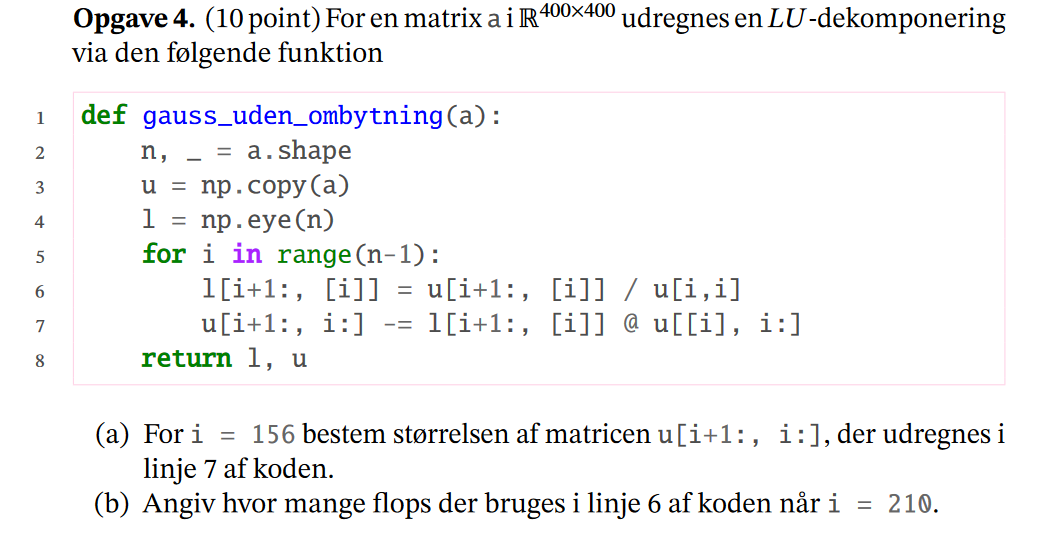

### (a)

In [6]:
def gauss_uden_ombytning(a):
    n, _ = a.shape
    u = np.copy(a)
    l = np.eye(n)
    for i in range(n-1):
        l[i+1:, [i]] = u[i+1:, [i]] / u[i,i]
        u[i+1:, i:] -= l[i+1:, [i]] @ u[[i], i:]
        if i == 156:
            big = u[i+1:, i:].shape
    return big

a = np.zeros((400,400))
print("størrelse =", gauss_uden_ombytning(a))

størrelse = (243, 244)


C:\Users\henri\AppData\Local\Temp\ipykernel_6164\3479636294.py:6: RuntimeWarning: invalid value encountered in divide
  l[i+1:, [i]] = u[i+1:, [i]] / u[i,i]


### (b)

In [7]:
400-211

189

Da det er gange med skalar er det $189 \cdot 1 = 189$ flops

## Opgave 8.3

### (b)

In [3]:
iris_dtype = np.dtype([ ('vals', float, (4,)),
                        ('art', np.str_, 16)])
vals, labels = np.loadtxt('iris/iris.data', dtype=iris_dtype, delimiter=',', unpack=True)
iris = vals.T

### (c)

In [3]:
iris.shape

(4, 150)

In [4]:
iris.dtype

dtype('float64')

In [17]:
u, s, vt = np.linalg.svd(iris, full_matrices=False)
print(u.shape, s.shape, vt.shape)

### (d)

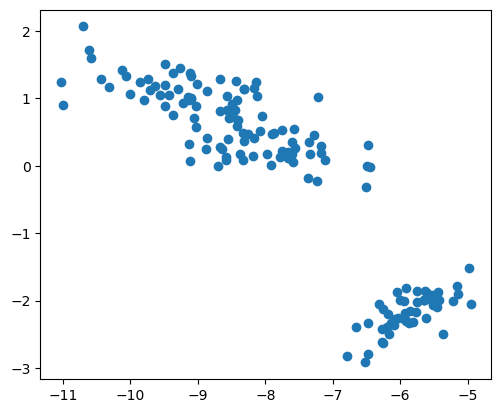

In [18]:
svt = np.diag(s) @ vt

fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(*svt[:2], 'o')

### (e)

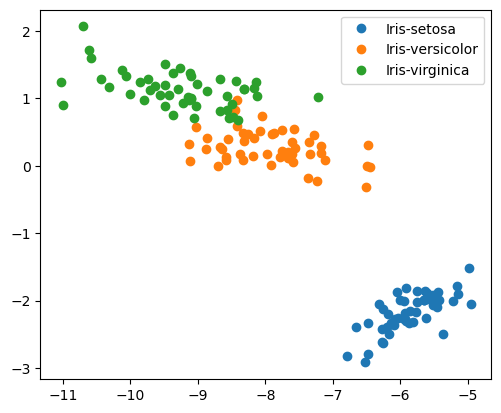

In [19]:
fig, ax = plt.subplots()
ax.set_aspect('equal')

for lab in np.unique(labels):
    ax.plot(*(svt[:2, labels == lab]), 'o', label=lab)
    ax.legend()

### (f)

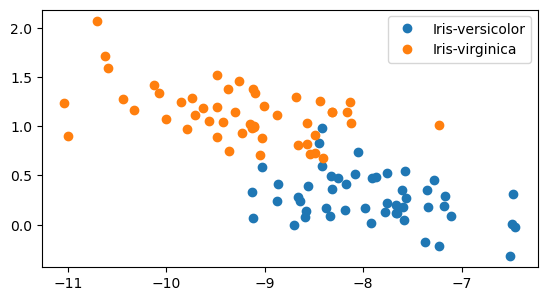

In [21]:
A = np.array([  [100, 0], 
                [0, 80]])

fig, ax = plt.subplots()
ax.set_aspect('equal')

for lab in np.unique(labels):
    if lab != 'Iris-setosa':
        ax.plot(*(svt[:2, labels == lab]), 'o', label=lab)
        ax.legend()

Pointen er at man ikke kan adskille dem, men det bare en andrew hygge opgave, så ikke vigtig.

## Opgave 8.4

### (a)

Vektorsamlingen antages at være lineær uafhængig:
$$
p(x) = s_{0} \cdot 1 + s_{1} \cdot x + s_{2} \cdot x^{3} = 0
$$

Differentieres der kan det ses at skalarerne skal være 0 alle sammen, før det går op, hvilket betyder at det passer med formen af en lineær uafhængig vektorsamling:
$$
\frac{d^{3}p}{dx^{3}} = 6 \cdot s_{2} = 0 \\
s_{2} = \frac{0}{6} = 0
$$

$$
\frac{dp}{dx} = s_{1} + 6 \cdot 0 \cdot x = 0 \\
s_{1} = 0 
$$

$$
p(x) = s_{0} \cdot 1 + 0 \cdot x + 0 \cdot x^{3} = 0 \\
s_{0} = 0
$$

### (b)

Forkert, den er faktisk lineært uafhængig for når man opstiller ligningssystemet med to afledte får man:
$$
\begin{bmatrix}
1 & e^{x} & e^{-x} & | & 0 \\
0 & e^{x} & -e^{-x} & | & 0 \\
0 & e^{x} & e^{-x} & | & 0
\end{bmatrix}
$$
hvilket somehow går op.

Vektorsamlingen antages at være lineær uafhængig:
$$
p(x) = s_{0} \cdot 1 + s_{1} \cdot e^{x} + s_{2} \cdot e^{-x} = 0
$$

Differentieres de får man

$$
\frac{dp}{dx} = s_{1} \cdot e^{x} - s_{2} \cdot e^{-x} = 0 \\
\Updownarrow \\
s_{1} \cdot e^{x} = s_{2} \cdot \frac{1}{e^{x}} \\
\Updownarrow \\
s_{1} \cdot e^{2x} = s_{2}
$$

Substitueres $s_{2}$ ind på den originale differentieret ligning får man
$$
s_{1} \cdot e^{x} - (s_{1} \cdot e^{2x}) \cdot e^{-x} = 0 \\
\Updownarrow \\
s_{1} \cdot e^{x} - s_{1} \cdot e^{x} = 0 \\
$$

Da $s_{1}$ kunne være et hvilket som helst tal, er vektorsamlingen ikke lineært uafhængig.

## Opgave 8.5

In [22]:
def f(a, b, c, sqrt):
    return (-b + sqrt(b**2 - 4 * a * c)) / (2 * a)

In [23]:
a = 2.0
b = 2.0
c = -1.0
offset = np.linspace(-1, 1, 200)

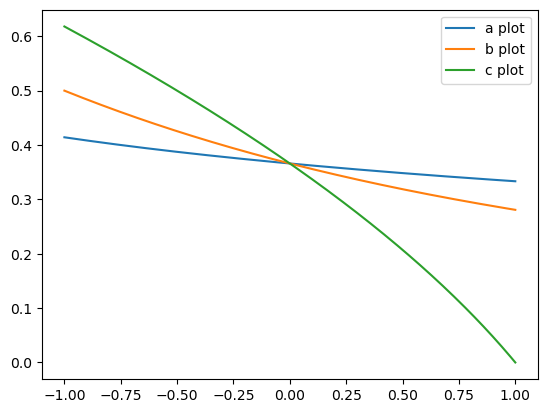

In [25]:
fig, ax = plt.subplots()
ax.plot(offset, (-b + np.sqrt(b**2 - 4 * (a + offset) * c)) / (2 * (a + offset)), label='a plot')
ax.plot(offset, (-(b + offset) + np.sqrt((b + offset)**2 - 4 * a * c)) / (2 * a), label='b plot')
ax.plot(offset, (-b + np.sqrt(b**2 - 4 * a * (c + offset))) / (2 * a), label='c plot')
ax.legend()

In [84]:
A, B, C = sp.symbols('A B C')
diff_a = sp.diff((-b + sp.sqrt(b**2 - 4 * A * c)) / (2 * A), A)
grad_a = diff_a.subs(sp.Symbol("A"), a)

In [83]:
diff_b = sp.diff((-B + sp.sqrt(B**2 - 4 * a * c)) / (2 * a), B)
grad_b = diff_b.subs(sp.Symbol("B"), b)

In [85]:
diff_c = sp.diff((-B + sp.sqrt(b**2 - 4 * a * C)) / (2 * a), C)
grad_c = diff_c.subs(sp.Symbol("C"), c)

In [86]:
print(f"({grad_a}, {grad_b}, {grad_c})")

(-0.0386751345948129, -0.105662432702594, -0.288675134594813)


Gradienten af c er størst hvilket giver mening ift. grafen, da c har største hældning visuelt.

In [100]:
koords = np.array([a, b, c])[:, np.newaxis]
grad_koords = np.array([grad_a, grad_b, grad_c], dtype=float)[:, np.newaxis]

kappa = (np.linalg.norm(koords) * np.linalg.norm(grad_koords)) / np.abs((-b + np.sqrt(b**2 - 4 * a * c)) / (2 * a))
print("Konditionstallet er:", kappa)

Konditionstallet er: 2.5394009448125736


Konditionstallet siger ikke og en skid om forskellen mellem tallene, men alle beregningerne er rigtig nok.

## Opgave 8.6 Spørg om det her

$$
x^{T} = 
\begin{bmatrix}
    x_0 & x_1
\end{bmatrix}
$$
$$
A = 
\begin{bmatrix}
    A_{00} & A_{01} \\
    A_{10} & A_{11}
\end{bmatrix}
$$
$$
y = 
\begin{bmatrix}
    y_0 \\
    y_1
\end{bmatrix}
$$

$$
x^{T} A y = y_0 \cdot (x_0 \cdot A_{00} + x_1 \cdot A_{01}) + y_1 \cdot (x_0 \cdot A_{10} + x_1 \cdot A_{11})
$$



Identitetsmatricen er den eneste der opfylder dette?